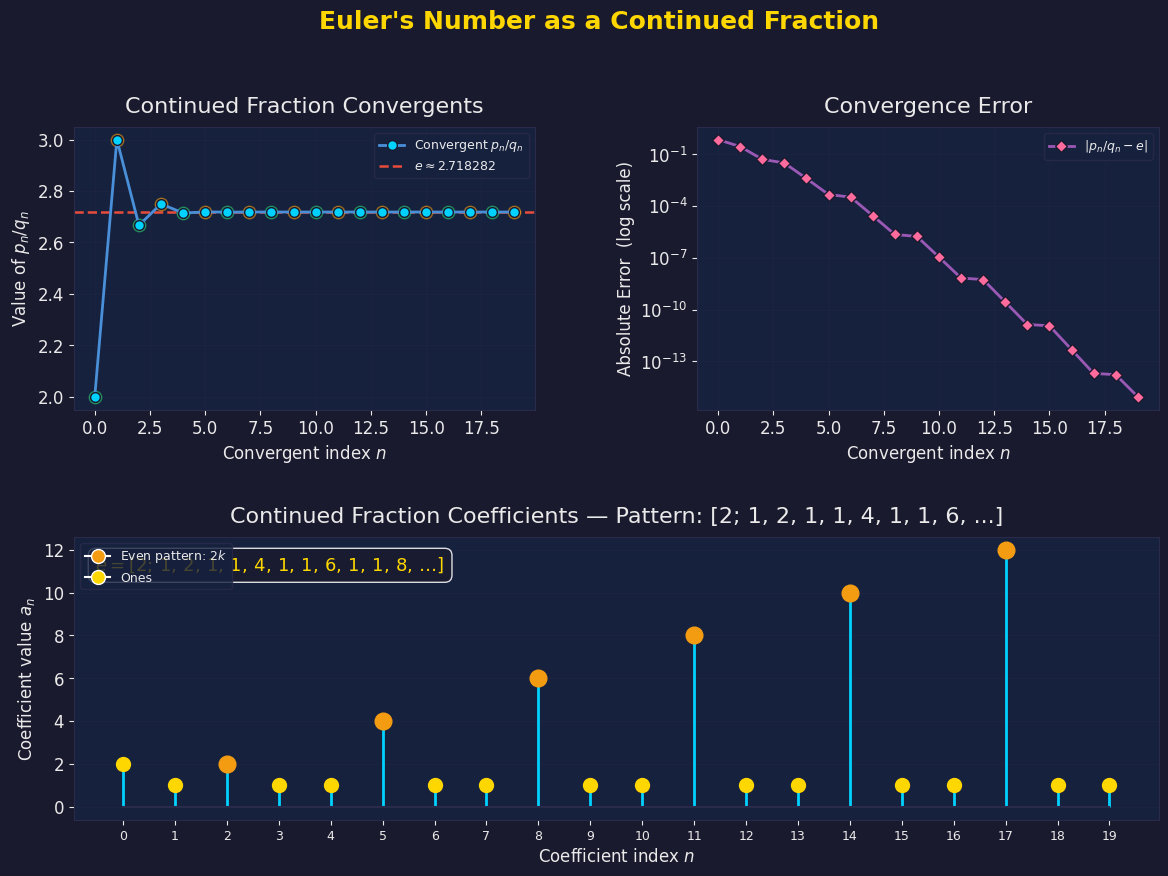

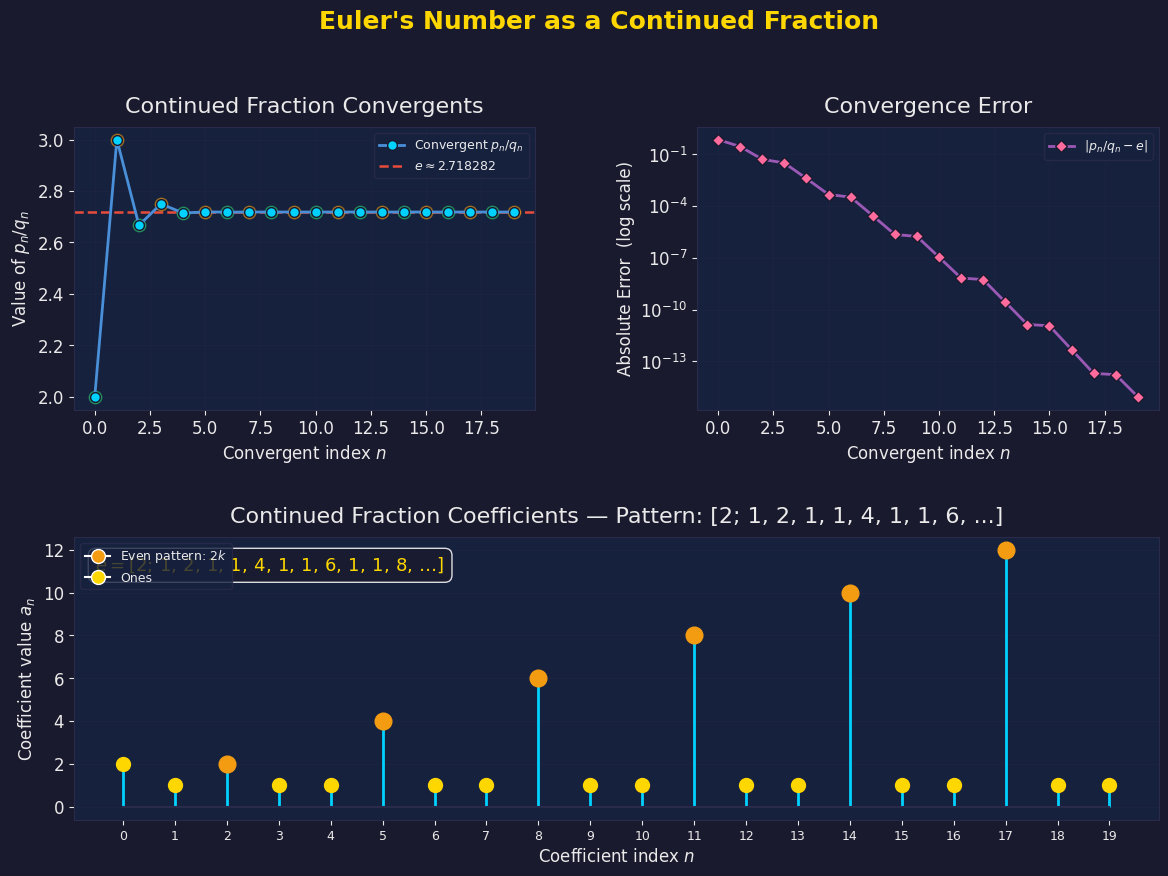

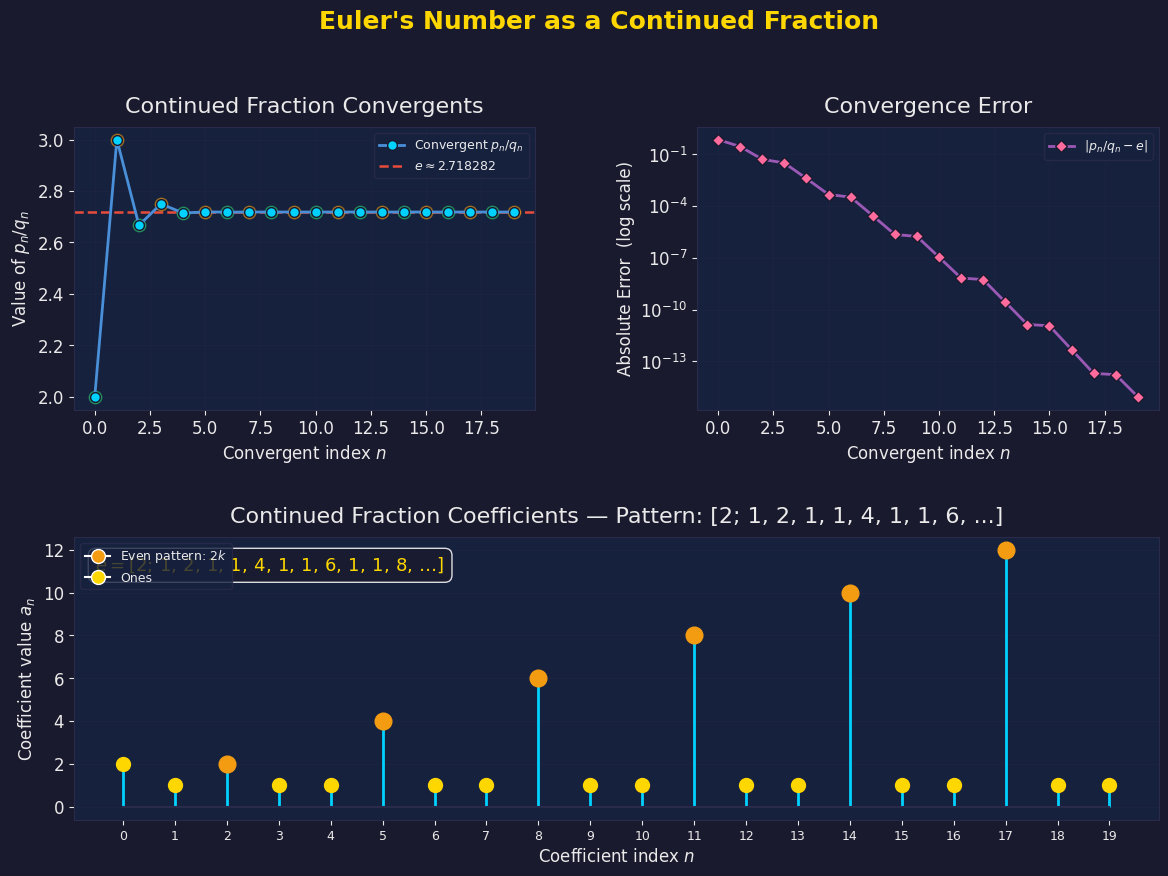

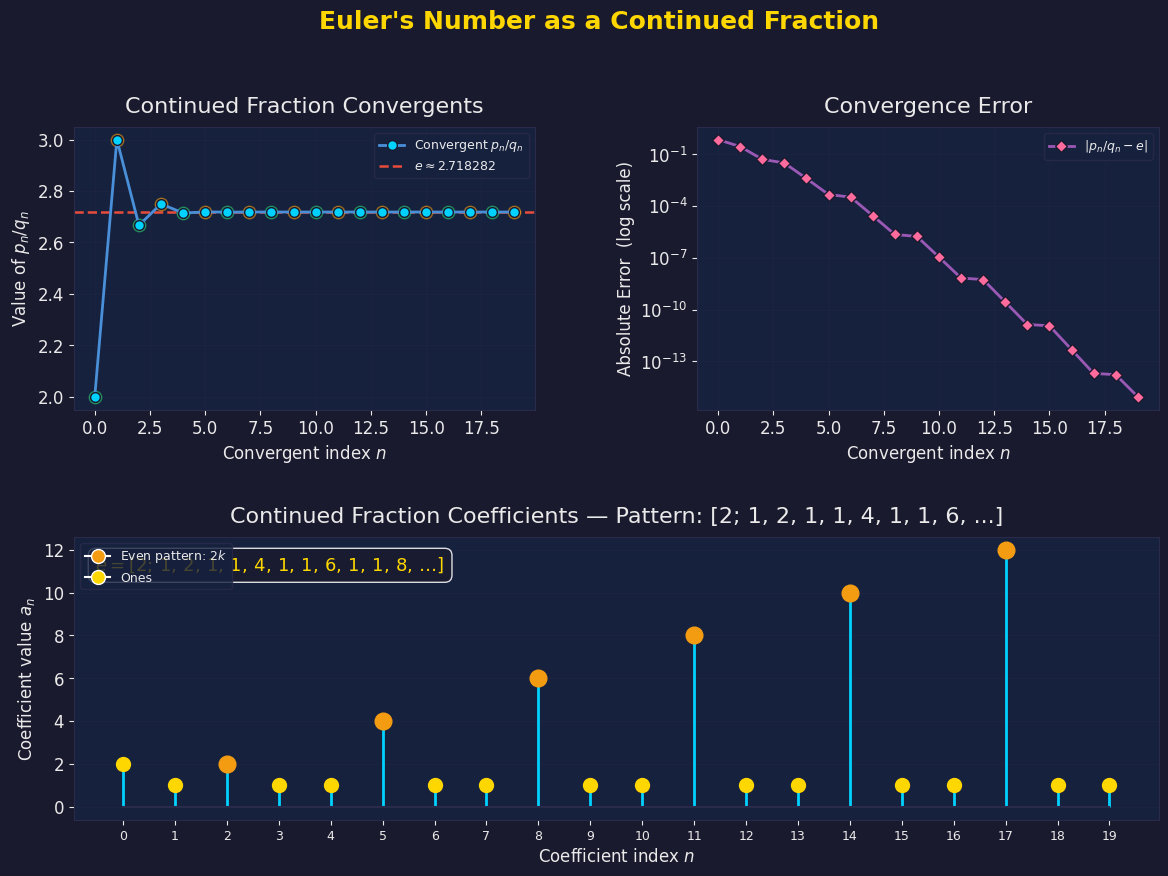

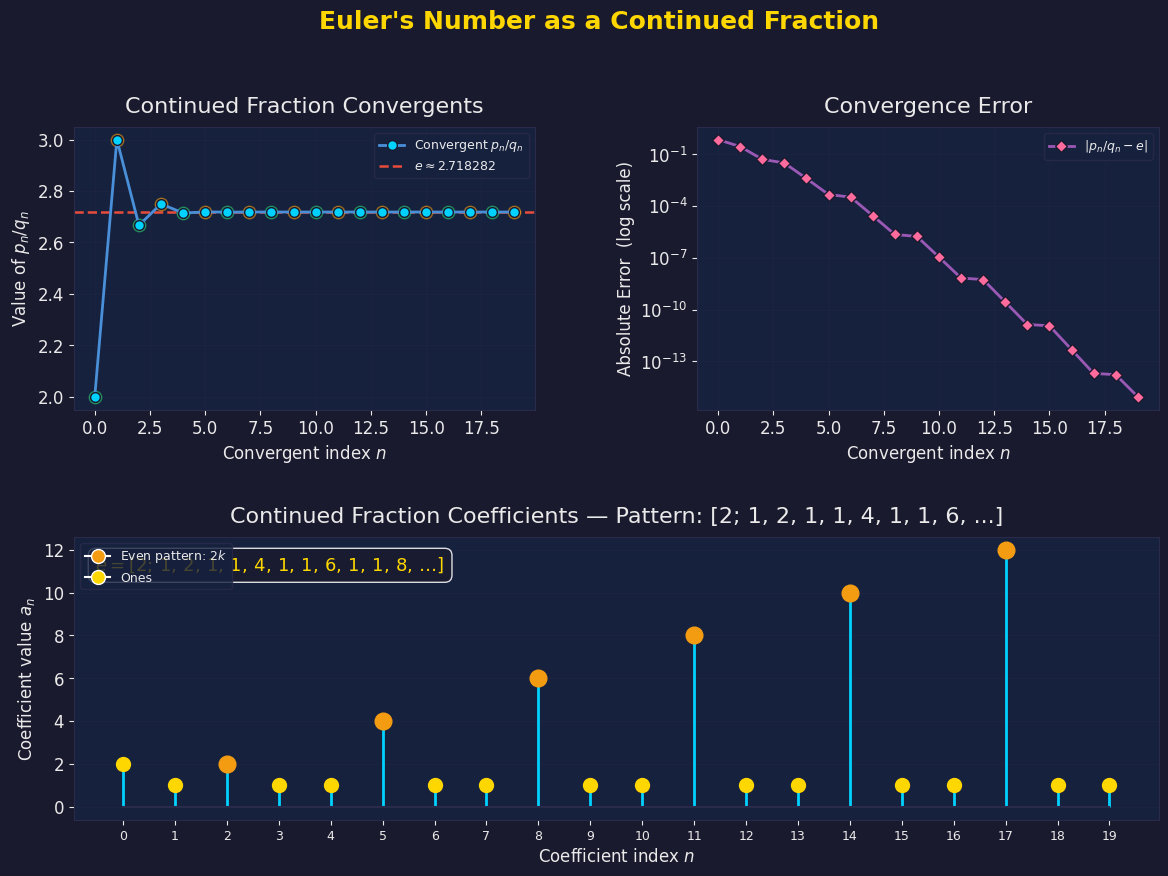

Done: continued_fraction


In [7]:
"""
continued_fraction.py — e as a continued fraction [2; 1, 2, 1, 1, 4, 1, 1, 6, ...]

Top plot: convergents p/q approaching e.
Bottom plot: stem plot showing coefficient pattern.
"""
%matplotlib inline
import matplotlib.pyplot as plt

# matplotlib.use('Agg')

import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))
from utils.plot_style import apply_euler_style, save_plot, COLORS
from utils.math_helpers import e_continued_fraction_coeffs, e_continued_fraction_convergent

E = math.e
N_TERMS = 20


def main():
    apply_euler_style()

    coeffs = e_continued_fraction_coeffs(N_TERMS)
    convergents = []
    for i in range(N_TERMS):
        p, q = e_continued_fraction_convergent(coeffs, i)
        convergents.append(p / q)

    indices = np.arange(N_TERMS)
    errors = [abs(c - E) for c in convergents]

    fig = plt.figure(figsize=(14, 9))
    fig.patch.set_facecolor(COLORS['bg_dark'])
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # --- Top-left: convergents vs e ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor(COLORS['bg_card'])
    ax1.plot(indices, convergents, color=COLORS['e_blue'], lw=2, marker='o',
             markersize=7, markerfacecolor=COLORS['e_cyan'],
             markeredgecolor=COLORS['bg_dark'], zorder=3, label='Convergent $p_n/q_n$')
    ax1.axhline(E, color=COLORS['e_red'], lw=1.8, ls='--', label=f'$e \\approx {E:.6f}$')

    # Shade alternating over/under
    for i, c in enumerate(convergents):
        col = COLORS['e_green'] if c < E else COLORS['e_orange']
        ax1.plot(i, c, 'o', color=col, markersize=9, alpha=0.5, zorder=2)

    ax1.set_xlabel('Convergent index $n$', color=COLORS['text'])
    ax1.set_ylabel('Value of $p_n / q_n$', color=COLORS['text'])
    ax1.set_title('Continued Fraction Convergents', color=COLORS['text'], pad=10)
    ax1.legend(facecolor=COLORS['bg_card'], edgecolor=COLORS['grid'], fontsize=9)
    ax1.grid(True, alpha=0.3, color=COLORS['grid'])

    # --- Top-right: error (semilogy) ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor(COLORS['bg_card'])
    valid = [(i, e_val) for i, e_val in enumerate(errors) if e_val > 1e-17]
    if valid:
        vi, ve = zip(*valid)
        ax2.semilogy(vi, ve, color=COLORS['e_purple'], lw=2, marker='D',
                     markersize=6, markerfacecolor=COLORS['e_pink'],
                     markeredgecolor=COLORS['bg_dark'], label=r'$|p_n/q_n - e|$')
    ax2.set_xlabel('Convergent index $n$', color=COLORS['text'])
    ax2.set_ylabel('Absolute Error  (log scale)', color=COLORS['text'])
    ax2.set_title('Convergence Error', color=COLORS['text'], pad=10)
    ax2.legend(facecolor=COLORS['bg_card'], edgecolor=COLORS['grid'], fontsize=9)
    ax2.grid(True, alpha=0.3, which='both', color=COLORS['grid'])

    # --- Bottom: stem plot of coefficients ---
    ax3 = fig.add_subplot(gs[1, :])
    ax3.set_facecolor(COLORS['bg_card'])

    markerline, stemlines, baseline = ax3.stem(
        indices, coeffs,
        linefmt=COLORS['e_cyan'],
        markerfmt='o',
        basefmt=COLORS['grid']
    )
    plt.setp(markerline, color=COLORS['e_gold'], markersize=10, zorder=5)
    plt.setp(stemlines, lw=2)

    # Colour the special "even" coefficients differently
    special_indices = [i for i in range(N_TERMS) if i % 3 == 2]
    for si in special_indices:
        ax3.plot(si, coeffs[si], 'o', color=COLORS['e_orange'], markersize=12,
                 zorder=6, label='2k coefficients' if si == special_indices[0] else '')

    # Annotate the pattern
    ax3.text(0.02, 0.88, r'$e = [2;\, 1,\,2,\,1,\,1,\,4,\,1,\,1,\,6,\,1,\,1,\,8,\,\ldots]$',
             transform=ax3.transAxes, color=COLORS['e_gold'], fontsize=13,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['bg_dark'], alpha=0.85))

    ax3.set_xlabel('Coefficient index $n$', color=COLORS['text'])
    ax3.set_ylabel('Coefficient value $a_n$', color=COLORS['text'])
    ax3.set_title('Continued Fraction Coefficients — Pattern: [2; 1, 2, 1, 1, 4, 1, 1, 6, ...]',
                  color=COLORS['text'], pad=10)
    ax3.set_xticks(indices)
    ax3.set_xticklabels([str(i) for i in indices], fontsize=9)
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=COLORS['e_orange'], markersize=10,
                          label='Even pattern: $2k$'),
               plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=COLORS['e_gold'], markersize=10,
                          label='Ones')]
    ax3.legend(handles=handles, facecolor=COLORS['bg_card'], edgecolor=COLORS['grid'], fontsize=9)
    ax3.grid(True, axis='y', alpha=0.3, color=COLORS['grid'])

    fig.suptitle("Euler's Number as a Continued Fraction", fontsize=18,
                 color=COLORS['e_gold'], y=1.01, fontweight='bold')

#     out_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'outputs')
#     save_plot(fig, 'continued_fraction', out_dir)
    plt.show()
    print("Done: continued_fraction")


if __name__ == '__main__':
    main()
